## Wildfire Prediction Models
Khushi Khan, Ella Chee, Willbert Clement Christianto  
DS4420: Machine Learning and Data Mining 2

In [ ]:
from utils import split_to_matrices, plot_img
from pathlib import Path
from PIL import ImageFile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import keras
import tensorflow as tf

# keras contains the tensorflow package, often used for fitting NNets
from keras.models import Model
from keras.layers import Dense, Input, Rescaling
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.optimizers import SGD
from keras.losses import binary_crossentropy

### Loading datasets

In [3]:
# Tracking all path files
data_root = Path("../data/raw")
num_channels = 3

# Load the images into a dataset
# - Infers subfolder labels (0 or 1)
# - Resizes images to (256, 256)
# - Color mode is RGB
# Documentation: https://keras.io/api/data_loading/image/
train_dataset = keras.utils.image_dataset_from_directory(Path(data_root / "train"), labels='inferred')
test_dataset = keras.utils.image_dataset_from_directory(Path(data_root / "test"), labels='inferred')
# valid_dataset = keras.utils.image_dataset_from_directory(Path(data_root / "valid"), labels='inferred')

Found 30250 files belonging to 2 classes.
Found 6300 files belonging to 2 classes.


In [4]:
# Checking that class names are correct
class_names = train_dataset.class_names
print(class_names)

['nowildfire', 'wildfire']


### Visualizing the training dataset and labels

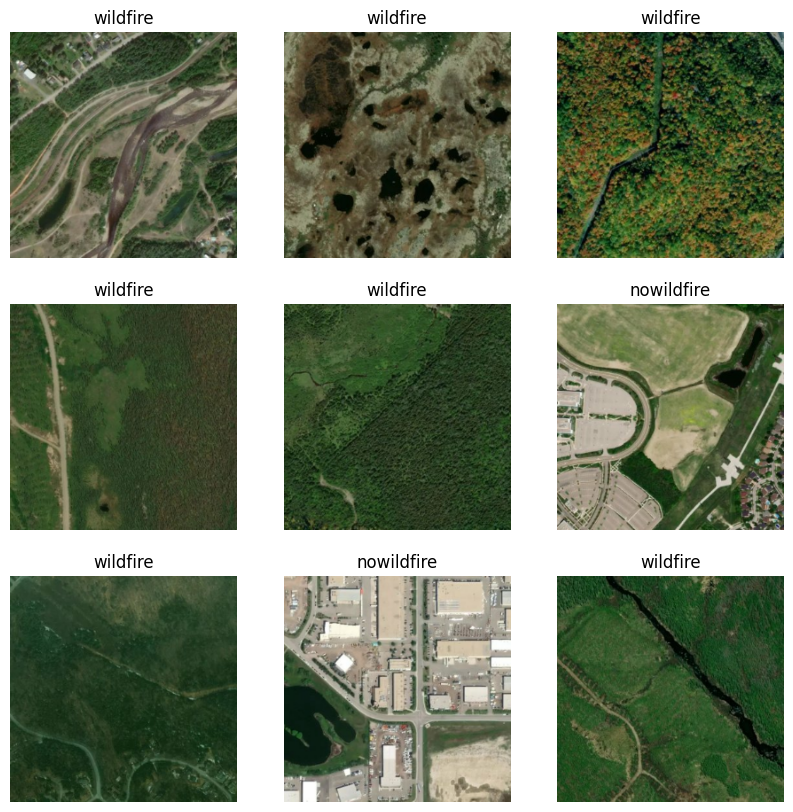

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

### Inspecting tensor shapes

In [6]:
print(train_dataset.element_spec)
print(test_dataset.element_spec)

(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [7]:
# Configuring the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

### Building the CNN

In [ ]:
num_classes = len(class_names)

img_dim = (256, 256)

# Instantiating a Keras tensor
inpx = Input(shape=(img_dim[0], img_dim[1], num_channels))

# Normalizing the data to be between 0 and 1
inpx = Rescaling(1./255, (img_dim[0], img_dim[1], num_channels))(inpx)

# Instantiating first convolutional and pooling layer
conv_layer = Conv2D(1, kernel_size=(3,3), strides=1, activation=None)(inpx)
pool_layer = MaxPooling2D(pool_size=(3,3))(conv_layer)

# Instantiating second convolutional and pooling layer
conv_layer2 = Conv2D(1, kernel_size=(3,3), strides=1, activation='sigmoid')(pool_layer)
pool_layer2 = MaxPooling2D(pool_size=(3,3))(conv_layer2)

# Flattening the images for the hidden layer/output
flat_G = Flatten()(conv_layer2)

# Defining first hidden layer
hid_layer = Dense(250, activation='relu')(flat_G)

# Defining output layer
out_layer = Dense(1, activation='sigmoid')(hid_layer)

In [35]:
model = Model([inpx], out_layer)

# Compile the model
model.compile(
    optimizer=SGD(),
    loss=binary_crossentropy,
    metrics=[
        'accuracy',
        keras.metrics.TruePositives(name='tp'),
        keras.metrics.FalsePositives(name='fp'),
        keras.metrics.TrueNegatives(name='tn'),
        keras.metrics.FalseNegatives(name='fn')
    ]
)

In [36]:
# View all the layers of the CNN
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_1CLONE             │ (None, 256, 256, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 1)    │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 84, 84, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 82, 82, 1)      │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6724)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 250)            │     1,681,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681,539 (6.41 MB)

 Trainable params: 1,681,539 (6.41 MB)

 Non-trainable params: 0 (0.00 B)

### Training the CNN

In [37]:
epochs = 10

history = model.fit(
    train_dataset,
    batch_size=32,
    epochs=epochs
)

Epoch 1/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.8607 - fn: 1244.0000 - fp: 2966.0000 - loss: 0.3742 - tn: 11518.0000 - tp: 14490.0000
Epoch 2/10
 12/946 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8744 - fn: 7.2500 - fp: 16.4167 - loss: 0.3808 - tn: 79.2500 - tp: 105.0833

c:\Users\khushi khan\Desktop\classes\DS4420-Project\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


946/946 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8771 - fn: 999.0000 - fp: 2714.0000 - loss: 0.3477 - tn: 11770.0000 - tp: 14735.0000
Epoch 3/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8918 - fn: 751.0000 - fp: 2518.0000 - loss: 0.3227 - tn: 11966.0000 - tp: 14983.0000
Epoch 4/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9058 - fn: 534.0000 - fp: 2314.0000 - loss: 0.2971 - tn: 12170.0000 - tp: 15200.0000
Epoch 5/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9193 - fn: 330.0000 - fp: 2109.0000 - loss: 0.2733 - tn: 12375.0000 - tp: 15404.0000
Epoch 6/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9281 - fn: 223.0000 - fp: 1949.0000 - loss: 0.2506 - tn: 12535.0000 - tp: 15511.0000
Epoch 7/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9364 - fn: 110.0000 - fp: 1813.0000 - loss: 0.2294 - tn: 12671.0000 - tp: 15624.0000
Epoch 8/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9412 - fn: 83.0000 - fp: 1693.00

### Evaluating the model's performance on the test data and examining performance metrics

In [54]:
score = model.evaluate(test_dataset)

model_metrics = {
    'Loss': round(score[0], 4),
    'Accuracy': round(score[1], 4),
    'True positives': score[2],
    'False positives': score[3],
    'True negatives': score[4],
    'False negatives': score[5]
}

for metric, score in model_metrics.items():
    print(f"{metric}: {score}")

197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7425 - fn: 723.0000 - fp: 891.0000 - loss: 0.6330 - tn: 1914.0000 - tp: 2740.0000
Loss: 0.633
Accuracy: 0.7425
True positives: 2740.0
False positives: 891.0
True negatives: 1914.0
False negatives: 723.0


c:\Users\khushi khan\Desktop\classes\DS4420-Project\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


It seems like the model is performing pretty well. The majority of its predictions are true positives and negatives.